# Natural Language Processing

## 0. Reminders


**Warning**: If you have any questions regarding the RNN Reminders, **DO NOT FEEL SHY** to ask as we will be using them extensively today

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/05/reminder/comparison.png" alt='Embedding' width="900px" />

- But what is $X$ and what is $y$?

### RNN-like time-series

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/05/reminder/exp_2.png" alt='Embedding' width="500px" />

- $X$ is what you know to predict $y$. More specifically, $X^{(t)}$ is what you know at time $t$
- $y$ is what you **want** to predict

In your particular case, just answer these questions:
- What do I know at time $t$, i.e. what is $X^{(t)}$
- What I am trying to predict?

Some examples?

## What is $X$?

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/05/reminder/data_structure.png" alt='Embedding' width="700px" />

X is just a sequence of observations! Univariate, multivariate, an image, ...
The point is that the observation is repeated through time! 

`X.shape = (N_SEQUENCES, N_OBSERVATIONS, N_FEATURES)`

**Warning:** The number of observations can vary from one sequence to another! (This is when you pad - we'll get back to that)

### What is $y$?

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/05/reminder/one_timeseries.png" alt='Embedding' width="500px" />

Let's consider that $X$ is a univariate time-series (of the stock-market for instance).

$y$ can be **anything**
- the value of your stock market the day after the last seen value
- the value of your stock market 10 days after the last seen value
- the value of your stock market [5, 7, 9] days after the last seen value
- a category that your stock market belongs to 
- the age of the children of the owner of the company 

**Warning**: $y$ has no reason per se to be values _seen_ in $X$

### `return_sequences=True` to predict a sequence of outputs

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/05/reminder/RNN_return_sequence.png" alt='Embedding' width="500px" />


You might want your algorithm to make a prediction after each step, rather than after seeing the whole sequence. For instance
- $y_1$ once you know $X^{(t=1)}$
- $y_2$ once you know $X^{(t=1)}$ and $X^{(t=2)}$ 
- $y_3$ once you know $X^{(t=1)}$, $X^{(t=2)}$ and  $X^{(t=3)}$
- etc

### Stack RNNs

There is another reason to have `return_sequence=True`. 

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/05/reminder/RNN_stack.png" alt='Embedding' width="700px" />


When you want the first RNN layer's output sequence to be fed into a second RNN layer.

```python
model.add(layers.LSTM(units=10, activation='tanh', return_sequences=True))
model.add(layers.LSTM(units=10, activation='tanh'))
model.add(layers.Dense(1))
```

### Padding data

As your input sequences probably don't have the same number of observations, you _have to_ **pad** them! The reason is purely for engineering: you have to feed a tensor into the Neural Network.

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/05/reminder/padding.png" alt='Embedding' width="800px" />


```python
from tensorflow.keras.preprocessing.sequence import pad_sequences
X_pad = pad_sequences(X, dtype='float32', padding='post', value=-1000)
model.add(layers.Masking(mask_value=-1000))
```


# 1. NLP (Examples)

### Language model

A language model is a model which attempts to predict the next word or character given a list of words or characters as an the input.

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/05/language_model.jpeg" alt='Embedding' width="800px" />

These models power things like predictive text (next word/emoji suggestions) on your phone. 

They are easy to implement, but it's not necessarily easy to obtain something meaningful!

### Text classification, such as sentiment analysis

Classification depending on a word, a sentence, a paragraph, ... 

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/05/sentiment_analysis.png" width="600px" />

The typical setting is **sentiment analysis**: Classify positive or negative sentences (but also happiness, sadness, joy, anger, ...).


### Sequence to sequence models

Given an input sequence, produce a corresponding output sequence. Typical application is language translation.

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/05/google_translate.png" alt='Google Translate' width="800px" />

# 2. How to feed Recurrent Neural Networks with words?

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/05/words_to_rnn.png" alt='Google Translate' width="800px" />

### 🚨 Clean your data before doing anything

You can: 
- Remove capital letters
- Remove accents and special characters
- Remove words that are too frequent or too rare
- ...

**But this is not the point of today's discussion**. For the rest of the day, **we will assume that the data is already clean**. 

### We have to convert words into numbers...

Text is also a form of recurrent data, where a sentence is a sequence of words, each being the _observation_.

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/05/sequence_of_words.png" alt='Google Translate' width="800px" />

### ...So they can be fed into a RNN

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/05/sequence_to_rnn.png" alt='Google Translate' width="800px" />

🤔 How do we choose the values of these inputs?

### Can *tokenization* be the answer?
&nbsp;  
Tokenizing:
> **Represent each word by a given number, like a dictionary**



Sentences become lists of integers! For instance: 

- `["this", "is", "good", "and", "this", "is", "bad"]` becomes
- `[9, 8, 1, 109, 9, 8, 32]`

Your tokenizing dictionary is
```python
{"this": 9, 
 "is": 8,
 "good": 1, ...}
```

## ❌ No, tokenization is not the solution

Because assigning a **random integer** to each word conveys a notion of **random ordering** that you don't want!

<br>🤔 Why not to use **OneHotEncoding** for words then?

Corpuses of unique words are way too big (usually >10,000 🤯)

## 2.1 ✅ High dimensional _Embedding_ is the solution

### Each word is represented by a vector ↗ of *chosen* length 

eg. 4D **_embedding_** space - also known as 4D latent space.

$$x_{dog} = (10, 0.2, 3.3, -2)$$
$$x_{cat} = (8, 2, 5.5, -5)$$
$$...$$

### 1D embedding ~ tokenization
<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/05/embedding_one_dimension.png" alt='Google Translate' width="800px" />

Here, we ordered the words according to whether they were negative or positive. This ordering makes some sense, but does not represent the full meaning of the words.

### 2D embedding

To further specify the meaning of each word, we add a dimension: we rank them according to their relative abstraction.

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/05/embedding_two_dimensions.png" alt='Google Translate' width="800px" />

### 3D embedding

In theory, we can add even more dimensions: 3, 4, 5, ... 

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/05/embedding_three_dimensions.png" alt='Google Translate' width="800px" />

Up to any number. Each dimension being one type of "ranking" we can think of for the words.

## 2.2 What makes a good embedding?

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/05/embeddings_cloud.png" width="500px" />

Semantically _close_ words are mathematically _close_ in this space

❗️ Usually, word embedding spaces are from **30** up to **300** dimensions ❗️

### Arithmetic on words?
We could dream of performing mathematical operations on the embeddings, which would have meaning in terms of natural language.

$$V(Queen) - V(King) + V(Man) = ? $$

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/05/word2vec.png" alt='Word2Vec' width="250px" />

Here, as the red vectors are similar, we could expect  $V(Queen) - V(King) = V(Woman) - V(Man)$.

So the answer we're looking for might be `Woman`.

### So now, each word is a vector

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/05/representation_1.png" alt='Word2Vec' width="80px" />

### And each sentence is a sequence of vectors

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/05/representation_2.png" alt='Word2Vec' width="300px" />

#### 🤔 But wait ... how do you choose these numbers? 

<br>

- Option 1: Find an embedding that is **specifically designed** for your task
- Option 2: Find an embedding that is **intrinsically good**, whatever your task is

# 3. Custom embedding with `layers.Embedding`

> Find an embedding that is **specifically designed** for your task

#### Let's replace the representation of each word by unknown values

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/05/embedding_layer_1.png" alt='Word2Vec' width="800px" />

### This can be considered as a Neural network layer

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/05/embedding_layer_2.png" alt='Word2Vec' width="600px" />

🔥 This neural network **learns the BEST representation** of each word **for your given task**

### Intermediary step: tokens

Neural networks' can't work directly on words, so you will still need to provide it with tokens.

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/05/embedding_layer_with_tokens.png" alt='Word2Vec' width="600px" />



### Our RNN input will look like this tensor

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/05/tensor_size.png" alt='Word2Vec' width="500px" />

`X.shape = (n_sentences, max_sentence_length, embedding_dim)`

#### 📺 So let's code all that now!

### Welcome [`Tokenizer`](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/text/Tokenizer)
```python
tk = Tokenizer()
tk.fit_on_texts(X)
X_token = tk.texts_to_sequences(X)
```

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

### Let's create some mock data
def get_mock_up_data():
    sentence_1 = 'Deep learning is super easy'
    sentence_2 = 'Deep learning was super bad and too long'
    sentence_3 = 'This is the best lecture of the camp!'

    X = [sentence_1, sentence_2, sentence_3]
    y = np.array([1., 0., 0.])

    ### Let's tokenize the vocabulary
    tk = Tokenizer()
    tk.fit_on_texts(X)
    vocab_size = len(tk.word_index)
    print(f'There are {vocab_size} different words in your corpus')
    X_token = tk.texts_to_sequences(X)

    ### Pad the inputs
    X_pad = pad_sequences(X_token, dtype='float32', padding='post')

    return X_pad, y, vocab_size

X_pad, y, vocab_size = get_mock_up_data()
print("X_pad.shape", X_pad.shape)
X_pad

There are 16 different words in your corpus
X_pad.shape (3, 8)


array([[ 1.,  2.,  3.,  4.,  6.,  0.,  0.,  0.],
       [ 1.,  2.,  7.,  4.,  8.,  9., 10., 11.],
       [12.,  3.,  5., 13., 14., 15.,  5., 16.]], dtype=float32)

### Welcome [`layers.Embedding`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Embedding)

```python
Embedding(input_dim=VOCAB_SIZE,
          input_length=MAX_SENTENCE_LENGTH,
          output_dim=EMBED_DIM,
          mask_zero=True)
```

In [ ]:
### Let's build the neural network now
from tensorflow.keras import layers, Sequential

# Size of your embedding space = size of the vector representing each word
embedding_size = 100

model = Sequential()
model.add(layers.Embedding(
    input_dim=vocab_size+1, # 16 +1 for the 0 padding
    input_length=8, # Max_sentence_length (optional, for model summary)
    output_dim=embedding_size, # 100
    mask_zero=True, # Built-in masking layer :)
))

model.add(layers.LSTM(20))
model.add(layers.Dense(1, activation="sigmoid"))
model.summary()

Model: "sequential_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, 8, 100)            1700      
_________________________________________________________________
lstm_4 (LSTM)                (None, 20)                9680      
_________________________________________________________________
dense_4 (Dense)              (None, 1)                 21        
Total params: 11,401
Trainable params: 11,401
Non-trainable params: 0
_________________________________________________________________


☝️ Number of params in Embedding = (`vocab_size` +1) * `embedding_size`

<br>

In [ ]:
print(f'Expected number of parameters: {(vocab_size+1) * embedding_size}')

Expected number of parameters : 1700


<br>☝️ 10,000 different words in 100 dimensions would mean **1M** parameters to learn

In [ ]:
model.compile(loss='binary_crossentropy',
              optimizer='rmsprop',
              metrics=['accuracy'])

model.fit(X_pad, y, epochs=5, batch_size=16, verbose=0)

### 🚨 Running an RNN with custom embedding can be slow

#### You usually deal with large Tensors

The size of your tensor depends on: 


<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/05/tensor_size.png" alt='Word2Vec' width="500px" />

`X.shape = (n_sentences, max_sentence_length, embedding_dim)`

You can reduce the size of your **embedding space** and **training data** to make training the model faster (esp. during prototyping). You will not get paid to stare at your screen ;)



<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/05/tensor_size.png" alt='Word2Vec' width="500px" />

But let's think about the `max_sentence_length`. If you have :
- 99 sentences of size 10
- 1 sentence of size 1000
Padding will create a looooot of zeros in the padded tensor!

This meaningless information slows down your computer.

So pad your data to a reasonable size! And in general (sentiment analysis), you don't need the entire sentence to extract the information you need.

#### Speed-up with a higher batch size


Remember when we told you to stick to a batch size of 16 or 32?

Well, this is what you should target. 

But **while prototyping**, especially with large datasets, to make it faster **you can use 64, 128 or 256**.

Remember that this is a tip for prototyping to make it faster! So be cautious ;)

# 4. Independent Embedding with `Word2Vec`

> Find an embedding that is **intrinsically** good, whatever the task

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/05/embedding_vs_word2vec.png" width="700px" />

Firstly, learn a good embedding independent of your final task, and then use it to feed your RNN.

🚨 The weights will **not** be optimized specifically for your task

How do we learn such an embedding?

### Welcome Word2Vec

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/05/Gensim-Word2Vec.png' width=300>

Word2Vec = "Words To Vectors"

Powerful embedding that is very fast and easy to train!

✅ you give it a list of sentences  
✅ it automatically learns a representation - an embedding - for each word it was trained on!

## 4.1 Training intuition

Split your training sentences into a sets of adjacent words

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/05/word2vec_training.png" width="500px" />

**Note:** The number of words considered to do the prediction (in each set) is called the _window_

The idea is to try to predict the middle word in blue based on its neighbors.

1. One Hot encode all your words
2. Train an auto-encoder to predict the word in the middle (e.g. brown) based on it's neighbors
3. Use the latent space (middle layer) as embedding!

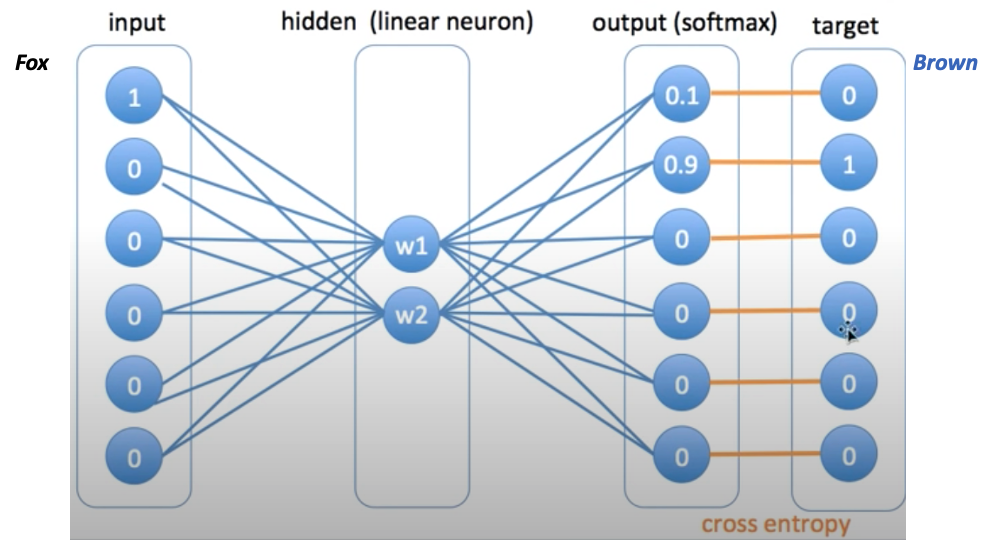

📺 [8 min video](https://www.youtube.com/watch?v=64qSgA66P-8)

**IN PRACTICE** It works as a black box
- just give it a text corpus
- and some parameters (`window size`, `embedding dimension`, ...)


## 💻 4.2 Word2vec: Implementation with `Gensim`

Robust implementation is not easy. 

The `gensim` package is _the reference_ if you want to embed your words using word2vec.

In [ ]:
### Let's get some text first

import tensorflow_datasets as tfds

train_data, test_data = tfds.load(name="imdb_reviews", split=["train", "test"],
                                            batch_size=-1, as_supervised=True)

train_sentences, train_labels = tfds.as_numpy(train_data)
test_sentences, test_labels = tfds.as_numpy(test_data)

# Let's check two sentences
train_sentences[0:2]

# We have to convert the sentences into list of words! The computer won't do it for us

array([b"This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it.",
       b'I have been known to fall asleep during films, but this is usually due to a combination of things including, really tired, being warm and comfortable on the sette and having just eaten a lot. However on this occasion I fell asleep because the film was rubbish. The plot 

In [ ]:
# Let's convert the list of sentences to a list of lists of words with a Keras utility function

from tensorflow.keras.preprocessing.text import text_to_word_sequence

X_train = [text_to_word_sequence(_.decode("utf-8")) for _ in train_sentences]
X_test = [text_to_word_sequence(_.decode("utf-8")) for _ in test_sentences]

X_train[0:2]

[['this',
  'was',
  'an',
  'absolutely',
  'terrible',
  'movie',
  "don't",
  'be',
  'lured',
  'in',
  'by',
  'christopher',
  'walken',
  'or',
  'michael',
  'ironside',
  'both',
  'are',
  'great',
  'actors',
  'but',
  'this',
  'must',
  'simply',
  'be',
  'their',
  'worst',
  'role',
  'in',
  'history',
  'even',
  'their',
  'great',
  'acting',
  'could',
  'not',
  'redeem',
  'this',
  "movie's",
  'ridiculous',
  'storyline',
  'this',
  'movie',
  'is',
  'an',
  'early',
  'nineties',
  'us',
  'propaganda',
  'piece',
  'the',
  'most',
  'pathetic',
  'scenes',
  'were',
  'those',
  'when',
  'the',
  'columbian',
  'rebels',
  'were',
  'making',
  'their',
  'cases',
  'for',
  'revolutions',
  'maria',
  'conchita',
  'alonso',
  'appeared',
  'phony',
  'and',
  'her',
  'pseudo',
  'love',
  'affair',
  'with',
  'walken',
  'was',
  'nothing',
  'but',
  'a',
  'pathetic',
  'emotional',
  'plug',
  'in',
  'a',
  'movie',
  'that',
  'was',
  'devoid',

In [ ]:
from gensim.models import Word2Vec

# This line trains an entire embedding for the words in your train set
word2vec = Word2Vec(sentences=X_train, vector_size=10)

In [ ]:
# Let's take a look at the representation of any word

word2vec.wv['hello']

array([ 0.11349579, -0.1805743 ,  0.42932147, -0.29310516, -0.01752834,
        0.43636566,  0.27717137, -0.6297742 , -1.3054028 , -1.1144987 ],
      dtype=float32)

In [ ]:
# Now let's look at the 10 closest words to `movie`

word2vec.wv.most_similar('movie', topn=10)

[('film', 0.9661346673965454),
 ('one', 0.9420779943466187),
 ('thing', 0.9319024682044983),
 ('sequel', 0.9264978766441345),
 ('experience', 0.9153682589530945),
 ('still', 0.9077871441841125),
 ('word', 0.9018585085868835),
 ('it', 0.8985790610313416),
 ('fun', 0.8862648010253906),
 ('credit', 0.8802122473716736)]

In [ ]:
# To control the size of the embedding space, you just have to set-up the `vector_size` keyword

word2vec = Word2Vec(sentences=X_train[:1000], vector_size=50) # We keep the training short by taking only 1000 sentences

len(word2vec.wv['computer'])

50

In [ ]:
# The Word2Vec learns a representation for words that are present more than `min_count` number of times
# This is to prevent learning representations based on a few examples only

word2vec = Word2Vec(sentences=X_train[:1000], vector_size=50, min_count=5)

try:
    len(word2vec.wv['columbian'])
except:
    print("word seen only less than 5 times, excluded from corpus")

word seen only less than 5 times, excluded from corpus


In [ ]:
# As mentioned ealier, Word2vec trains an internal Neural network whose goal is to predict a word in a corpus
# based on the words around it. This part of the sentence is called the window.
# Its size corresponds to the number of words around word W used to predict this word W


word2vec = Word2Vec(sentences=X_train[:10000], vector_size=100, window=5, min_count=1)

### Pre-trained Word2Vec (transfer learning)

In [ ]:
# Instead of training it on your training set (especially if it is very small), you can directly
# load a pretrained embedding

import gensim.downloader

print(list(gensim.downloader.info()['models'].keys()))

model_wiki = gensim.downloader.load('glove-wiki-gigaword-50')

['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200', '__testing_word2vec-matrix-synopsis']


In [ ]:
model_wiki.most_similar('movie', topn=10)

[('movies', 0.9322481155395508),
 ('film', 0.9310100078582764),
 ('films', 0.8937394618988037),
 ('comedy', 0.8902585506439209),
 ('hollywood', 0.8718216419219971),
 ('drama', 0.8341657519340515),
 ('sequel', 0.8222616314888),
 ('animated', 0.8216581344604492),
 ('remake', 0.812495768070221),
 ('show', 0.8105834126472473)]

## 4.2 Arithmetic on words

As mentioned earlier, we might expect to have

$$V(Queen) - V(King) = V(Woman) - V(Man)$$ 

where $V( ... )$  corresponds to the vectorial embedding of a given word.

To check it, lets look at the vectors that are the closest to the results of 

$$V(Queen) - V(King) + V(Man)$$

In [ ]:
word2vec = Word2Vec(sentences=X_train[:10000], vector_size=30, window=2, min_count=10)

v_queen = word2vec.wv['queen']
v_king = word2vec.wv['king']
v_man = word2vec.wv['man']

v_result = v_queen - v_king + v_man

word2vec.wv.similar_by_vector(v_result)

# You just did arithmetic directly on words!

[('girl', 0.9156383275985718),
 ('woman', 0.9044826030731201),
 ('man', 0.8929860591888428),
 ('guy', 0.8837186694145203),
 ('boy', 0.8256024718284607),
 ('cop', 0.7879610061645508),
 ('kid', 0.7701660394668579),
 ('town', 0.7109383344650269),
 ('edie', 0.7088533639907837),
 ('child', 0.7063576579093933)]

### Conclusion? `layers.Embedding` or Word2Vec?


<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/05/embedding_vs_word2vec_2.png" width="600px" />

👈 The left option allows you to have a representation that is perfectly suited to your task! However, it increases the number of parameters to learn, and thus:
- the time of each epoch (more parameters to optimize during back-propagation)
- the time to converge (because more parameters to find overall)

👉 On the other hand, word2vec is not specifically designed for your task (may be sub-optimal) but training it is very fast! You will also be able to optimize your RNN faster as you'll have less parameters.
- ❗ Prefer Word2Vec on small corpus (esp. with transfer learning)

### But to be honest. We lied. A little

We told you that the only way to do NLP is with a RNN. 

And this is not true. 

There is another one. That you have already seen.

Any idea?

## Sequences of observations are represented by matrix


<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/05/image_structure.png" width="500px" />

### Any idea what else we can use to work on text?

## Maybe this comparison will help:

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/05/image_comparison.png" width="700px" />

### You see what can be used on language?

# 🔥 5. CNNs for NLP (advanced)

## We used 2D convolutions on images

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/05/cnn_on_images.png" width="300px" />

The convolution can move in both directions, up & down, and, left & right

## 2D convolutions do not make much sense on text data

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/05/cnn_on_text_2D.png" width="700px" />

- Each row corresponds to a coordinate in the embedding space.
- This ordering is arbitrary.
- We should never look at "half the embedding" of a word
- Convolutions should not look for "relations" between the top rows and bottom rows!

👉 Convolutions should not convolve over the vertical axis

## 1D convolutions is the answer

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/05/cnn_on_text_1D.png" width="400px" />

One-dimensional convolutions (`layers.Conv1D(...)`) are exactly doing what you want : there are convolutions that "slide" along the word axis, word-by-word.

❗️❗️ The **Kernel-size** (here 2) equals the **number of words upon which the convolution is computed** (through the kernel weights)

In [ ]:
# RNN
rnn = Sequential([
    layers.Embedding(input_dim=5000, input_length=20, output_dim=30, mask_zero=True),
    layers.LSTM(20),
    layers.Dense(1, activation="sigmoid")
])


# Conv1D
cnn = Sequential([
    layers.Embedding(input_dim=5000, input_length=20, output_dim=30, mask_zero=True),
    layers.Conv1D(20, kernel_size=3),
    layers.Flatten(),
    layers.Dense(1, activation="sigmoid"),
])

In [ ]:
print(rnn.summary())
print(cnn.summary())

Model: "sequential_16"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_11 (Embedding)     (None, 20, 30)            150000    
_________________________________________________________________
lstm_10 (LSTM)               (None, 20)                4080      
_________________________________________________________________
dense_15 (Dense)             (None, 1)                 21        
Total params: 154,101
Trainable params: 154,101
Non-trainable params: 0
_________________________________________________________________
None
Model: "sequential_17"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_12 (Embedding)     (None, 20, 30)            150000    
_________________________________________________________________
conv1d_5 (Conv1D)            (None, 18, 20)            1820      
___________________

#### A CNN can also replace a RNN in a Word2Vec stack

We just showed how to replace the RNN layer with a CNN layer in the left part, with an Embedding layer. 

You can do exactly the same with a word2vec embedding! 


**The embedding is independent of the second layer (RNN or CNN)**




## This is the end of the _theoretical_ part

Although, there are many Deep Learning wonders that you might encounter in your future, and you should have at least heard of them to know what people are talking about.

### So now: sit back, relax, & listen ;)

# 6. Attention

**Adding attention mechanism to an RNN**

<img alt='Transformer' src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/05/general_knowledge/attention.jpeg' style="height: 400px;">

Info: 
- 📺 [Stanford CS224N lecture](https://youtu.be/XXtpJxZBa2c?t=3725)
- 📚 [Technical blog post](https://towardsdatascience.com/intuitive-understanding-of-attention-mechanism-in-deep-learning-6c9482aecf4f)  


**Transformers: attention is all you need**

<img alt='Transformer' src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/05/general_knowledge/transformer.png' style="height: 400px;">

Stay tuned for the next unit!

### Bibliography
* [CS224N: Natural Language Processing with Deep Learning by Stanford University](https://www.youtube.com/playlist?list=PLoROMvodv4rOhcuXMZkNm7j3fVwBBY42z) (recommended)
* [92 step-by-step videos by Hugo Larochelle.](https://www.youtube.com/watch?v=SGZ6BttHMPw&list=PL6Xpj9I5qXYEcOhn7TqghAJ6NAPrNmUBH)